In [114]:
# Install the libraries that are not available by default

#!pip install catboost
#!pip install lightgbm

In [14]:
# Import the libraries

import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

In [20]:
# Read the input train and test housing dataset
# https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

TrainDF_HousingData = pd.read_csv(r"C:\Users\ACER\Desktop\Kranthi\DataScience_Desktop\Projects\DataMites_Projects\PRCP-1020-HousePricePred\SampleSubmissionFromKaggle\train.csv")
TestDF_HousingData = pd.read_csv(r"C:\Users\ACER\Desktop\Kranthi\DataScience_Desktop\Projects\DataMites_Projects\PRCP-1020-HousePricePred\SampleSubmissionFromKaggle\test.csv")

TestDF_HousingData.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal


### All Columns / Features information

In [44]:
# Get the shape - Get total number of Records and columns

TrainDF_HousingData.shape
# 1460 records with 81 features

(1460, 81)

In [45]:
# Get the names of all the columns in the housing data set

#HousingData_TrainDF.columns.tolist()
TrainDF_HousingData.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [36]:
# To get the names of only numeric columns

#TrainDF_HousingData.select_dtypes(include=['number']).columns.tolist()
TrainDF_HousingData.select_dtypes(include=['number']).columns

# Count the number of numerical features
# len(TrainDF_HousingData.select_dtypes(include=['number']).columns)
# len(TrainDF_HousingData.dtypes[TrainDF_HousingData.dtypes != 'object'])
# 38

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [88]:
# Get the name and data types of all the numeric features

TrainDF_HousingData.dtypes[TrainDF_HousingData.dtypes!='object']

Id                 int64
MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
SalePrice          int64
dtype: object

In [89]:
# To get the names of only categorical columns

#TrainDF_HousingData.select_dtypes(include=['object', 'category']).columns.tolist()
TrainDF_HousingData.select_dtypes(include=['object', 'category']).columns

# Count the number of categorical features
# len(TrainDF_HousingData.select_dtypes(include=['object', 'category']).columns)
# len(TrainDF_HousingData.dtypes[TrainDF_HousingData.dtypes == 'object'])
# 43

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [91]:
# Get the name and data types of all the categorical features

TrainDF_HousingData.dtypes[TrainDF_HousingData.dtypes=='object']

MSZoning         object
Street           object
Alley            object
LotShape         object
LandContour      object
Utilities        object
LotConfig        object
LandSlope        object
Neighborhood     object
Condition1       object
Condition2       object
BldgType         object
HouseStyle       object
RoofStyle        object
RoofMatl         object
Exterior1st      object
Exterior2nd      object
MasVnrType       object
ExterQual        object
ExterCond        object
Foundation       object
BsmtQual         object
BsmtCond         object
BsmtExposure     object
BsmtFinType1     object
BsmtFinType2     object
Heating          object
HeatingQC        object
CentralAir       object
Electrical       object
KitchenQual      object
Functional       object
FireplaceQu      object
GarageType       object
GarageFinish     object
GarageQual       object
GarageCond       object
PavedDrive       object
PoolQC           object
Fence            object
MiscFeature      object
SaleType        

### Summary of all the numeric columns

In [52]:
# Display data of only numeric features

TrainDF_HousingData.select_dtypes(include=['number']).head(2)

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500


In [49]:
# Summary of only numerical features

TrainDF_HousingData.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Summary of all the non-numeric columns

In [55]:
# Display data of only categorical features

TrainDF_HousingData.select_dtypes(include=['object', 'category']).head(2)

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


In [50]:
# Summary of only categorical features

TrainDF_HousingData.describe(include='O')

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


In [69]:
# Information about each of the columns like Column name, not null, data types...

TrainDF_HousingData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [57]:
# Check the null count in each column

TrainDF_HousingData.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

<Axes: >

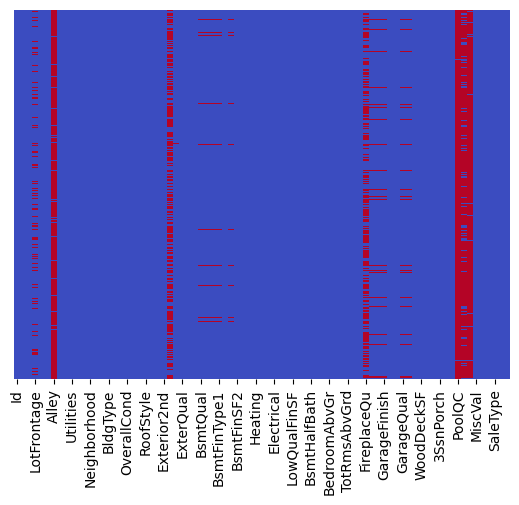

In [70]:
# Create a heatmap to visualize the nulls in the features

sns.heatmap(TrainDF_HousingData.isnull(),yticklabels=False,cbar=False,cmap='coolwarm')

### Get the columns that have 50% of records as null values

In [71]:
# Check which columns have 50% of records as null values

for i in range(0,80):
    # Set the percentage
    percentage = 40
    
    # Get the null count of each column
    null_Count = sum(TrainDF_HousingData[TrainDF_HousingData.columns[i]].isnull())

    # Check if the null count is > 50% of the total record count
    if null_Count >= len(TrainDF_HousingData)*percentage/100:
        print('Column', TrainDF_HousingData.columns[i], 'has', null_Count, 'null values, which is greater than',percentage,'percent of total records')

    # Check which columns have records with nulls in between 5% and 50%
    #elif (null_Count > len(TrainDF_HousingData)*0.05) and (null_Count < len(TrainDF_HousingData)*0.5):
    #    print('Column', TrainDF_HousingData.columns[i], 'has', null_Count, 'null values')

Column Alley has 1369 null values, which is greater than 40 percent of total records
Column MasVnrType has 872 null values, which is greater than 40 percent of total records
Column FireplaceQu has 690 null values, which is greater than 40 percent of total records
Column PoolQC has 1453 null values, which is greater than 40 percent of total records
Column Fence has 1179 null values, which is greater than 40 percent of total records
Column MiscFeature has 1406 null values, which is greater than 40 percent of total records


# Feature/ Column wise analysis
- Check for nulls and their count
- Check for unique value counts in case of categorical
- Check for outliers using the Scatterplot, it also helps to understand how the feature is directly impacting the SalesPrice.

## MSSubClass Feature

In [93]:
# Check if there are nulls in the MSSubClass Feature/ Column

sum(TrainDF_HousingData.MSSubClass.isnull())

0

In [94]:
# Check the unique values in the HouMSSubClass Feature
sorted(TrainDF_HousingData.MSSubClass.unique())

[np.int64(20),
 np.int64(30),
 np.int64(40),
 np.int64(45),
 np.int64(50),
 np.int64(60),
 np.int64(70),
 np.int64(75),
 np.int64(80),
 np.int64(85),
 np.int64(90),
 np.int64(120),
 np.int64(160),
 np.int64(180),
 np.int64(190)]

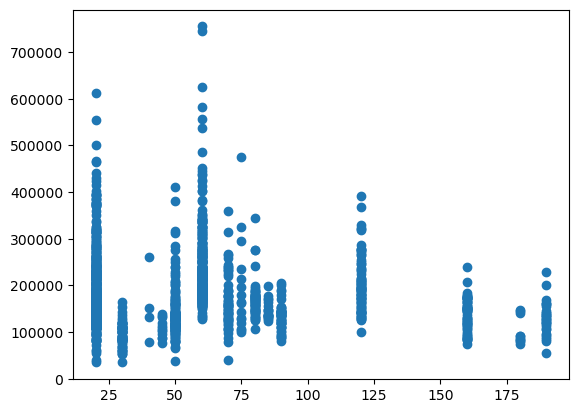

In [95]:
# Draw a scatterplot to see the relationship between MSSubClass Feature and Output feature(SalePrice)

plt.scatter(x = 'MSSubClass', y = 'SalePrice', data = TrainDF_HousingData)

In [96]:
# Check the records with very high Sale price 

TrainDF_HousingData.query('MSSubClass == 60 and SalePrice > 500000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
769,770,60,RL,47.0,53504,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,538000
803,804,60,RL,107.0,13891,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2009,New,Partial,582933
1046,1047,60,RL,85.0,16056,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,New,Partial,556581
1169,1170,60,RL,118.0,35760,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,625000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


## MSZoning Feature

In [97]:
# Check if there are nulls 

sum(TrainDF_HousingData.MSZoning.isnull())

0

In [98]:
# Since this is a categorical feature, Check each value and its count

TrainDF_HousingData.MSZoning.value_counts()

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

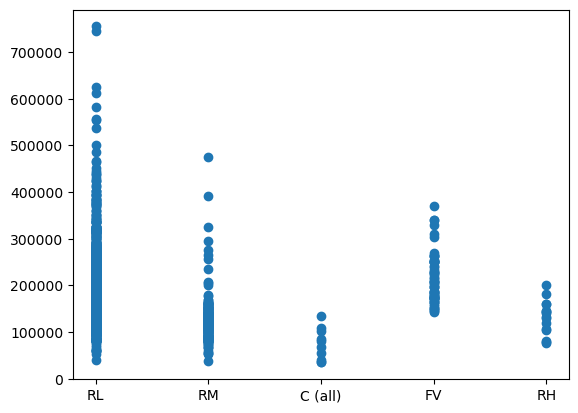

In [134]:
plt.scatter(x = 'MSZoning', y = 'SalePrice',data = TrainDF_HousingData)

In [135]:
TrainDF_HousingData.query('MSZoning == "RL" and SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


## LotFrontage Feature

In [99]:
# LotFrontage Feature - Linear feet of street connected to property and see how it impacts Sale Price

# Check if there are null values in this column
sum(TrainDF_HousingData.LotFrontage.isnull())

259

In [100]:
#sorted(TrainDF_HousingData.LotFrontage.unique())

#Housing_Data.LotFrontage.min()
#21
#Housing_Data.LotFrontage.max()
#313

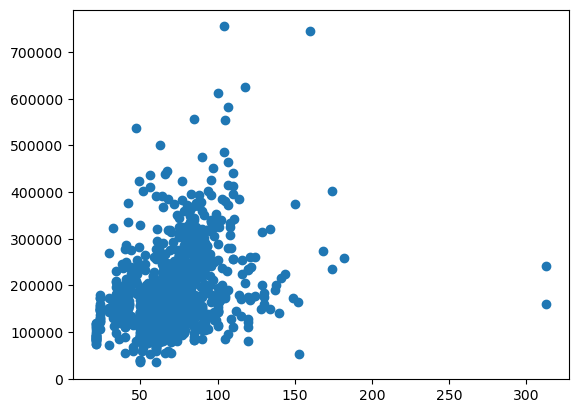

In [101]:
# Plot a scatterplot to get the visualation of the feature 

plt.scatter(x = 'LotFrontage', y = 'SalePrice', data = TrainDF_HousingData)

In [102]:
# Find value lotFrontage when the sale price is maximum

TrainDF_HousingData.query('LotFrontage > 50 and LotFrontage < 170 and SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


In [103]:
# Check outliers in lotFrontage

TrainDF_HousingData.query('LotFrontage > 190')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
934,935,20,RL,313.0,27650,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,11,2008,WD,Normal,242000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


## BsmtCond Feature

In [109]:
sum(TrainDF_HousingData.BsmtCond.isnull())

37

In [108]:
TrainDF_HousingData.BsmtCond.value_counts()

BsmtCond
TA    1311
Gd      65
Fa      45
Po       2
Name: count, dtype: int64

## BsmtQual Feature

In [139]:
sum(TrainDF_HousingData.BsmtQual.isnull())

37

In [140]:
TrainDF_HousingData.BsmtQual.value_counts()

BsmtQual
TA    649
Gd    618
Ex    121
Fa     35
Name: count, dtype: int64

## LotArea Feature

In [104]:
# LotArea Feature and see how it impacts Sale Price - Lot size in square feet

# Check if there are null values 
sum(TrainDF_HousingData.LotArea.isnull())

0

In [105]:
# Check total number of unique values
len(TrainDF_HousingData.LotArea.unique())
# 1073

TrainDF_HousingData.LotArea.min()
#1,300 sft

TrainDF_HousingData.LotArea.max()
#2,15,245 sft

# This usually should be directly proportional to the sale price

215245

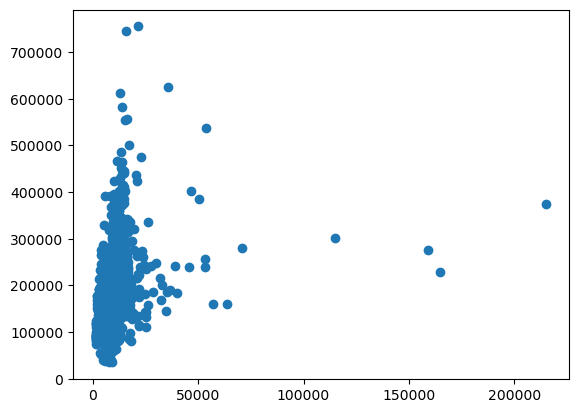

In [106]:
plt.scatter(x = 'LotArea', y = 'SalePrice', data = TrainDF_HousingData)

In [107]:
# Find value LotArea when the sale price is maximum

TrainDF_HousingData.query('LotArea > 1300 and LotArea < 50000 and SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


In [108]:
# Check for outliers

TrainDF_HousingData.query('LotArea > 75000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
249,250,50,RL,NaN,159000,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,Shed,500,6,2007,WD,Normal,277000
313,314,20,RL,150.0,215245,Pave,NaN,IR3,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,375000
335,336,190,RL,NaN,164660,Grvl,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,Shed,700,8,2008,WD,Normal,228950
706,707,20,RL,NaN,115149,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,302000


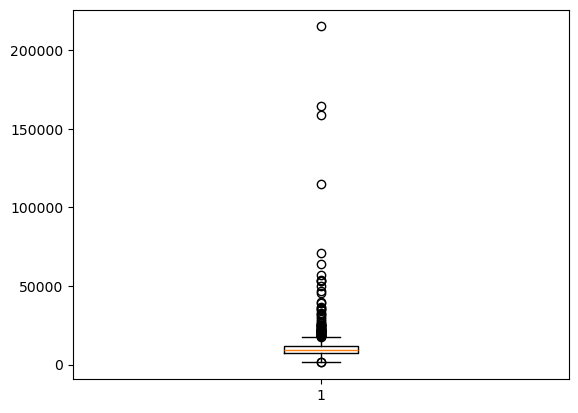

In [109]:
# Box plot to check for outliers

plt.boxplot(TrainDF_HousingData.LotArea)
plt.show()

In [110]:
# ZScore to find the outliers

pd.Series(stats.zscore(TrainDF_HousingData['LotArea'])).sort_values().tail(5)

451     6.037793
706    10.486449
249    14.881285
335    15.448542
313    20.518273
dtype: float64

In [111]:
# Manual way to find out the outliers

Mean = TrainDF_HousingData.LotArea.mean()
SD = TrainDF_HousingData.LotArea.std()
Highest_Allowed_Value = Mean + (3*SD)
# 40460.62287932922
Lowest_Allowed_Value = Mean - (3*SD)
# -19426.966714945658

In [112]:
# Outliers as per the manul calculation

TrainDF_HousingData.query('LotArea < -19426.966714945658')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


In [159]:
# Outliers as per the manul calculation

TrainDF_HousingData.query('LotArea > 40460.62287932922')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
53,54,20,RL,68.0,50271,Pave,NaN,IR1,Low,AllPub,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,385000
249,250,50,RL,NaN,159000,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,Shed,500,6,2007,WD,Normal,277000
313,314,20,RL,150.0,215245,Pave,NaN,IR3,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,375000
335,336,190,RL,NaN,164660,Grvl,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,Shed,700,8,2008,WD,Normal,228950
384,385,60,RL,NaN,53107,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,240000
451,452,20,RL,62.0,70761,Pave,NaN,IR1,Low,AllPub,...,0,NaN,NaN,NaN,0,12,2006,WD,Normal,280000
457,458,20,RL,NaN,53227,Pave,NaN,IR1,Low,AllPub,...,0,NaN,NaN,NaN,0,3,2008,WD,Normal,256000
661,662,60,RL,52.0,46589,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,402000
706,707,20,RL,NaN,115149,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,302000
769,770,60,RL,47.0,53504,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,538000


## FireplaceQu Feature

In [160]:
sum(TrainDF_HousingData.FireplaceQu.isnull())

690

In [161]:
TrainDF_HousingData.FireplaceQu.value_counts()

FireplaceQu
Gd    380
TA    313
Fa     33
Ex     24
Po     20
Name: count, dtype: int64

## GarageType Feature 

In [162]:
sum(TrainDF_HousingData.GarageType.isnull())

81

In [163]:
TrainDF_HousingData.GarageType.value_counts()

GarageType
Attchd     870
Detchd     387
BuiltIn     88
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64

## GarageYrBlt Feature

In [266]:
sum(TrainDF_HousingData.GarageYrBlt.isnull())

81

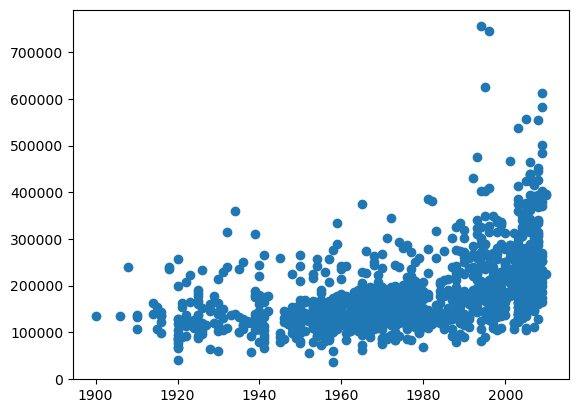

In [267]:
plt.scatter(x = 'GarageYrBlt', y = 'SalePrice', data = TrainDF_HousingData)

In [167]:
TrainDF_HousingData.GarageYrBlt.min()

1900.0

In [168]:
TrainDF_HousingData.GarageYrBlt.max()

2010.0

In [171]:
TrainDF_HousingData.query('GarageYrBlt <= 1900')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
93,94,190,C (all),60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2007,WD,Normal,133900


## GarageFinish Feature

In [173]:
sum(TrainDF_HousingData.GarageFinish.isnull())

81

In [176]:
TrainDF_HousingData.GarageFinish.value_counts()

GarageFinish
Unf    605
RFn    422
Fin    352
Name: count, dtype: int64

## GarageQual Feature

In [186]:
sum(TrainDF_HousingData.GarageQual.isnull())

81

In [187]:
TrainDF_HousingData.GarageQual.value_counts()

GarageQual
TA    1311
Fa      48
Gd      14
Ex       3
Po       3
Name: count, dtype: int64

## GarageCond Feature

In [184]:
sum(TrainDF_HousingData.GarageCond.isnull())

81

In [185]:
TrainDF_HousingData.GarageCond.value_counts()

GarageCond
TA    1326
Fa      35
Gd       9
Po       7
Ex       2
Name: count, dtype: int64

## PoolQC Feature

In [191]:
sum(TrainDF_HousingData.PoolQC.isnull())

1453

## Fence Feature 

In [193]:
sum(TrainDF_HousingData.Fence.isnull())

1179

## MiscFeature Feature

In [194]:
sum(TrainDF_HousingData.MiscFeature.isnull())

1406

## MasVnrArea Feature

In [209]:
TrainDF_HousingData.MasVnrArea.max()

1600.0

In [210]:
TrainDF_HousingData.MasVnrArea.min()

0.0

In [201]:
sum(TrainDF_HousingData.MasVnrArea.isnull())

8

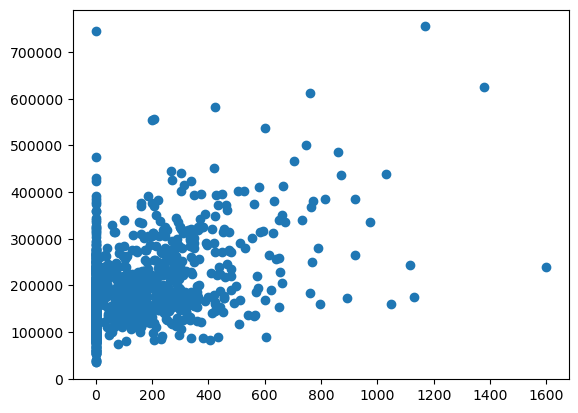

In [203]:
plt.scatter(x = 'MasVnrArea', y = 'SalePrice', data = TrainDF_HousingData)

In [205]:
# Manual way to find out the outliers

Mean = TrainDF_HousingData.MasVnrArea.mean()
SD = TrainDF_HousingData.MasVnrArea.std()
Highest_Allowed_Value = Mean + (3*SD)
# 646.8838814696435
Lowest_Allowed_Value = Mean - (3*SD)
# -439.51335805366557

In [180]:
TrainDF_HousingData.query('MasVnrArea > 1500')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
297,298,60,FV,66.0,7399,Pave,Pave,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,239000


In [178]:
TrainDF_HousingData.query('MasVnrArea > 646.8838814696435').head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
37,38,20,RL,74.0,8532,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,153000
58,59,60,RL,66.0,13682,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,10,2006,New,Partial,438780
70,71,20,RL,95.0,13651,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2007,WD,Normal,244000


## BsmtExposure Feature

In [217]:
sum(TrainDF_HousingData.BsmtExposure.isnull())

38

In [218]:
TrainDF_HousingData.BsmtExposure.value_counts()

BsmtExposure
No    953
Av    221
Gd    134
Mn    114
Name: count, dtype: int64

## BsmtFinType1 Feature

In [181]:
sum(TrainDF_HousingData.BsmtFinType1.isnull())

37

In [182]:
TrainDF_HousingData.BsmtFinType1.value_counts()

BsmtFinType1
Unf    430
GLQ    418
ALQ    220
BLQ    148
Rec    133
LwQ     74
Name: count, dtype: int64

## BsmtFinType2 Feature

In [239]:
sum(TrainDF_HousingData.BsmtFinType2.isnull())

38

In [240]:
TrainDF_HousingData.BsmtFinType2.value_counts()

BsmtFinType2
Unf    1256
Rec      54
LwQ      46
BLQ      33
ALQ      19
GLQ      14
Name: count, dtype: int64

## Utilities Feature

In [228]:
sum(TrainDF_HousingData.Utilities.isnull())

0

In [229]:
TrainDF_HousingData.Utilities.value_counts()

Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

## Exterior1st Feature

In [230]:
sum(TrainDF_HousingData.Exterior1st.isnull())

0

In [231]:
TrainDF_HousingData.Exterior1st.value_counts()

Exterior1st
VinylSd    515
HdBoard    222
MetalSd    220
Wd Sdng    206
Plywood    108
CemntBd     61
BrkFace     50
WdShing     26
Stucco      25
AsbShng     20
BrkComm      2
Stone        2
AsphShn      1
ImStucc      1
CBlock       1
Name: count, dtype: int64

## Exterior2nd Feature

In [241]:
sum(TrainDF_HousingData.Exterior2nd.isnull())

0

In [242]:
TrainDF_HousingData.Exterior2nd.value_counts()

Exterior2nd
VinylSd    504
MetalSd    214
HdBoard    207
Wd Sdng    197
Plywood    142
CmentBd     60
Wd Shng     38
Stucco      26
BrkFace     25
AsbShng     20
ImStucc     10
Brk Cmn      7
Stone        5
AsphShn      3
Other        1
CBlock       1
Name: count, dtype: int64

## BsmtFinSF1 Feature

In [183]:
TrainDF_HousingData.BsmtFinSF1.min()

0

In [184]:
TrainDF_HousingData.BsmtFinSF1.max()

5644

In [185]:
sum(TrainDF_HousingData.BsmtFinSF1.isnull())

0

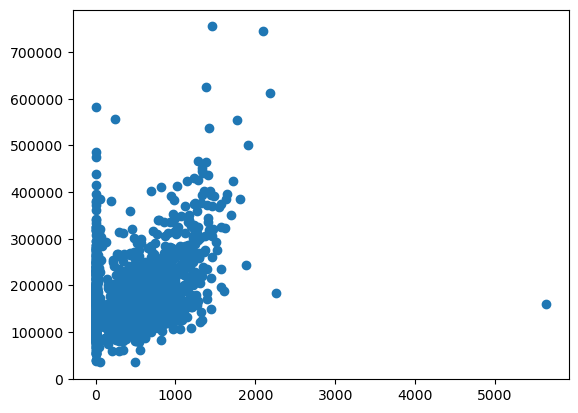

In [186]:
plt.scatter(x = 'BsmtFinSF1', y = 'SalePrice', data = TrainDF_HousingData)

In [258]:
TrainDF_HousingData.query('BsmtFinSF1 > 3000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


## BsmtFinSF2 Feature

In [259]:
TrainDF_HousingData.BsmtFinSF2.min()

0

In [260]:
TrainDF_HousingData.BsmtFinSF2.max()

1474

In [261]:
sum(TrainDF_HousingData.BsmtFinSF2.isnull())

0

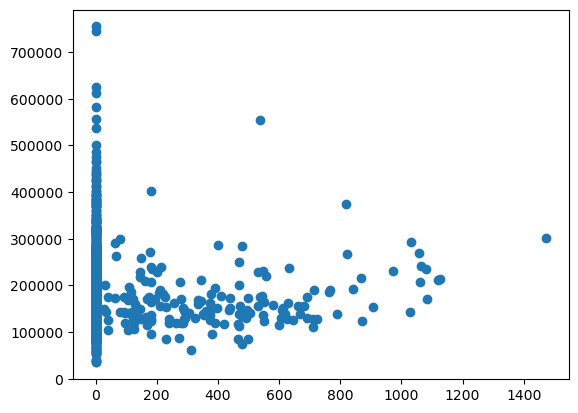

In [262]:
plt.scatter(x = 'BsmtFinSF2', y = 'SalePrice', data = TrainDF_HousingData)

In [187]:
TrainDF_HousingData.query('BsmtFinSF2 > 400 and SalePrice > 500000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
440,441,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,555000


## BsmtUnfSF Feature

In [188]:
TrainDF_HousingData.BsmtUnfSF.min()

0

In [189]:
TrainDF_HousingData.BsmtUnfSF.max()

2336

In [190]:
sum(TrainDF_HousingData.BsmtUnfSF.isnull())

0

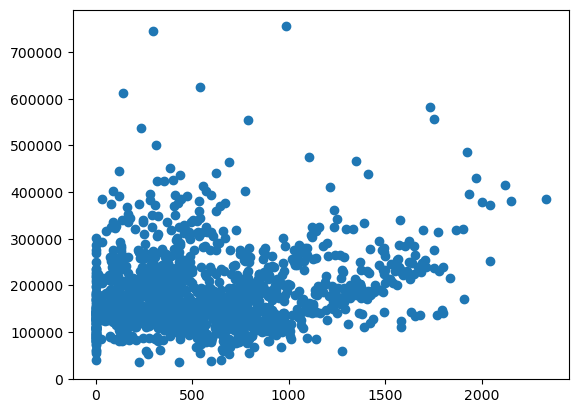

In [267]:
plt.scatter(x = 'BsmtUnfSF', y = 'SalePrice', data = TrainDF_HousingData)

## TotalBsmtSF Feature

In [268]:
TrainDF_HousingData.TotalBsmtSF.min()

0

In [269]:
TrainDF_HousingData.TotalBsmtSF.max()

6110

In [270]:
sum(TrainDF_HousingData.TotalBsmtSF.isnull())

0

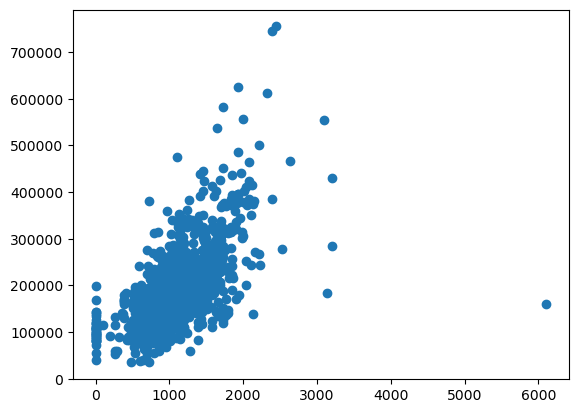

In [271]:
plt.scatter(x = 'TotalBsmtSF', y = 'SalePrice', data = TrainDF_HousingData)

In [273]:
TrainDF_HousingData.query('TotalBsmtSF > 3500')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


## BsmtFullBath Feature

In [220]:
TrainDF_HousingData.BsmtFullBath.min()

0

In [221]:
TrainDF_HousingData.BsmtFullBath.max()

3

In [222]:
sum(TrainDF_HousingData.BsmtFullBath.isnull())

0

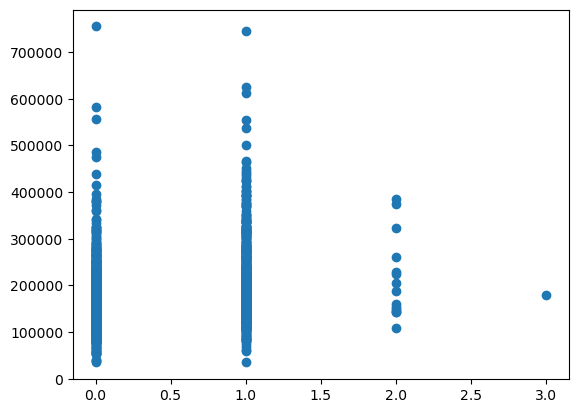

In [223]:
plt.scatter(x = 'BsmtFullBath', y = 'SalePrice', data = TrainDF_HousingData)

In [227]:
TrainDF_HousingData.query('BsmtFullBath == 3')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
738,739,90,RL,60.0,10800,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2009,WD,Alloca,179000


In [228]:
TrainDF_HousingData.BsmtFullBath.value_counts()

BsmtFullBath
0    856
1    588
2     15
3      1
Name: count, dtype: int64

## BsmtHalfBath Feature

In [229]:
TrainDF_HousingData.BsmtHalfBath.min()

0

In [230]:
TrainDF_HousingData.BsmtHalfBath.max()

2

In [231]:
sum(TrainDF_HousingData.BsmtHalfBath.isnull())

0

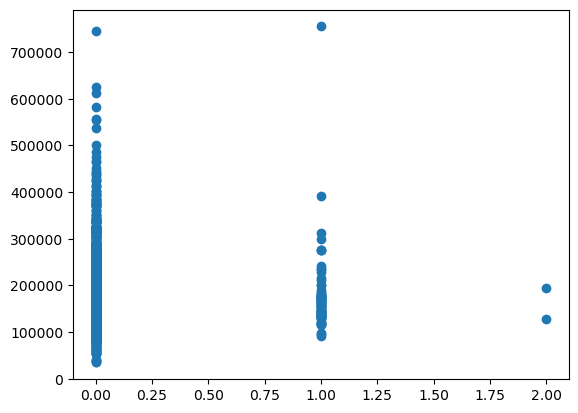

In [232]:
plt.scatter(x = 'BsmtHalfBath', y = 'SalePrice', data = TrainDF_HousingData)

In [242]:
np.unique(stats.zscore(TrainDF_HousingData['BsmtHalfBath']))

array([-0.24106104,  3.94880935,  8.13867973])

In [244]:
TrainDF_HousingData.query('BsmtHalfBath == 2')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
597,598,120,RL,53.0,3922,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2007,New,Partial,194201
954,955,90,RL,35.0,9400,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2006,WD,AdjLand,127500


In [245]:
TrainDF_HousingData.BsmtHalfBath.value_counts()

BsmtHalfBath
0    1378
1      80
2       2
Name: count, dtype: int64

## KitchenQual Feature

In [288]:
sum(TrainDF_HousingData.KitchenQual.isnull())

0

In [289]:
TrainDF_HousingData.KitchenQual.value_counts()

KitchenQual
TA    735
Gd    586
Ex    100
Fa     39
Name: count, dtype: int64

## Functional Feature

In [293]:
sum(TrainDF_HousingData.Functional.isnull())

0

In [296]:
TrainDF_HousingData.Functional.value_counts()

Functional
Typ     1360
Min2      34
Min1      31
Mod       15
Maj1      14
Maj2       5
Sev        1
Name: count, dtype: int64

## GarageCars Feature

In [298]:
sum(TrainDF_HousingData.GarageCars.isnull())

0

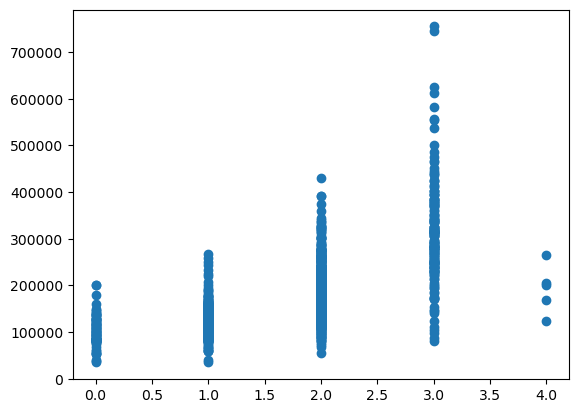

In [268]:
plt.scatter(x = 'GarageCars', y = 'SalePrice', data = TrainDF_HousingData)

## GarageArea Feature

In [306]:
TrainDF_HousingData.GarageArea.min()

0

In [307]:
TrainDF_HousingData.GarageArea.max()

1418

In [308]:
sum(TrainDF_HousingData.GarageArea.isnull())

0

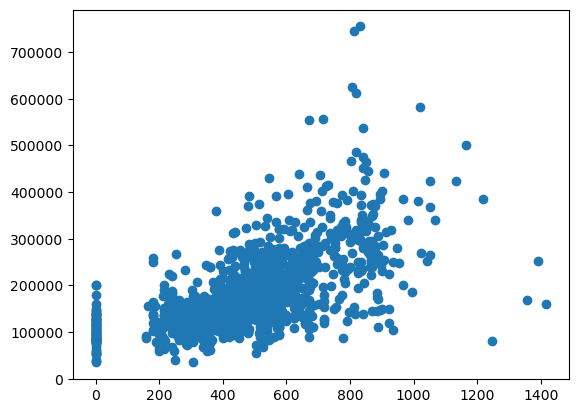

In [309]:
plt.scatter(x = 'GarageArea', y = 'SalePrice', data = TrainDF_HousingData)

In [269]:
TrainDF_HousingData.query('GarageArea > 1200')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
581,582,20,RL,98.0,12704,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2009,New,Partial,253293
825,826,20,RL,114.0,14803,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,New,Partial,385000
1061,1062,30,C (all),120.0,18000,Grvl,NaN,Reg,Low,AllPub,...,0,NaN,NaN,Shed,560,8,2008,ConLD,Normal,81000
1190,1191,190,RL,NaN,32463,Pave,NaN,Reg,Low,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,168000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


## SaleType Feature

In [310]:
sum(TrainDF_HousingData.SaleType.isnull())

0

In [311]:
TrainDF_HousingData.SaleType.value_counts()

SaleType
WD       1267
New       122
COD        43
ConLD       9
ConLI       5
ConLw       5
CWD         4
Oth         3
Con         2
Name: count, dtype: int64

## OverallQual Feature

In [121]:
sum(TrainDF_HousingData.OverallQual.isnull())

0

In [146]:
TrainDF_HousingData.OverallQual.value_counts()

OverallQual
5     397
6     374
7     319
8     168
4     116
9      43
3      20
10     18
2       3
1       2
Name: count, dtype: int64

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

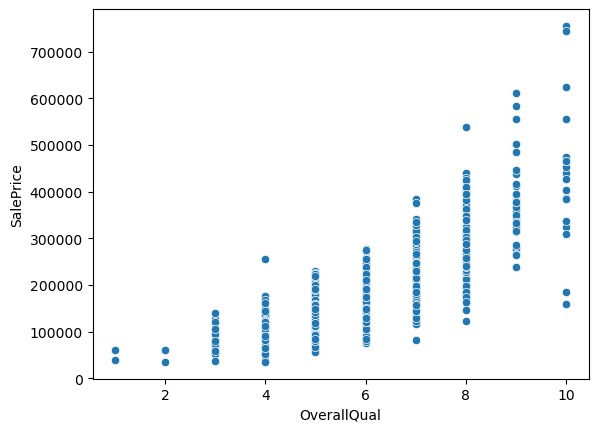

In [152]:
sns.scatterplot(x = 'OverallQual', y = 'SalePrice', data = TrainDF_HousingData)

In [155]:
TrainDF_HousingData.query('OverallQual == 10 and SalePrice < 200000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


## OverallCond Feature

In [123]:
sum(TrainDF_HousingData.OverallCond.isnull())

0

In [124]:
TrainDF_HousingData.OverallCond.value_counts()

OverallCond
5    821
6    252
7    205
8     72
4     57
3     25
9     22
2      5
1      1
Name: count, dtype: int64

<Axes: xlabel='OverallCond', ylabel='SalePrice'>

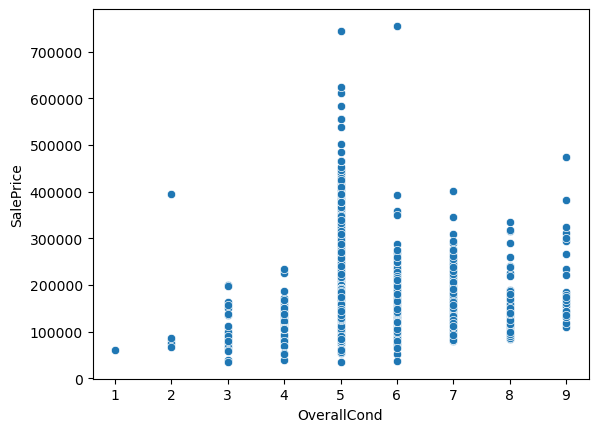

In [157]:
sns.scatterplot(x = 'OverallCond', y = 'SalePrice', data = TrainDF_HousingData)

In [166]:
TrainDF_HousingData.query('OverallCond == 2 and SalePrice > 300000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
378,379,20,RL,88.0,11394,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,New,Partial,394432


In [168]:
TrainDF_HousingData.query('OverallCond == 5 and SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


In [169]:
TrainDF_HousingData.query('OverallCond == 6 and SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000


## YearBuilt Feature

In [170]:
TrainDF_HousingData.YearBuilt.min()

1872

In [171]:
TrainDF_HousingData.YearBuilt.max()

2010

In [172]:
sum(TrainDF_HousingData.YearBuilt.isnull())

0

<Axes: xlabel='YearBuilt', ylabel='SalePrice'>

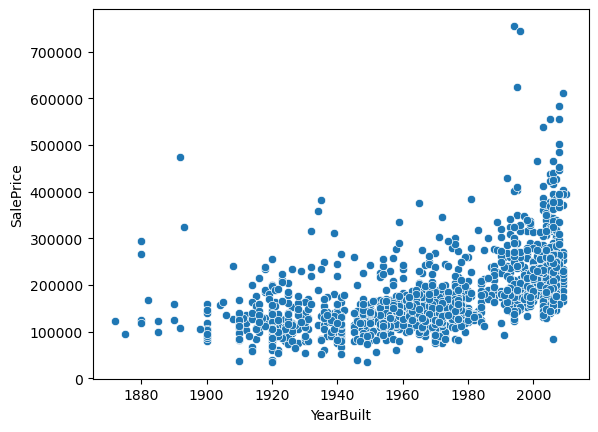

In [174]:
sns.scatterplot(x = 'YearBuilt', y = 'SalePrice', data = TrainDF_HousingData)

In [175]:
TrainDF_HousingData.query('YearBuilt < 1900 and SalePrice > 400000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000


## YearRemodAdd Feature

In [142]:
TrainDF_HousingData.YearRemodAdd.min()

1950

In [143]:
TrainDF_HousingData.YearRemodAdd.max()

2010

In [144]:
sum(TrainDF_HousingData.YearRemodAdd.isnull())

0

<Axes: xlabel='YearRemodAdd', ylabel='SalePrice'>

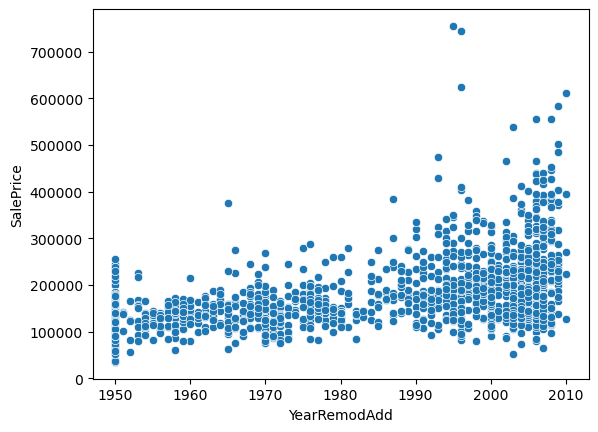

In [176]:
sns.scatterplot(x = 'YearRemodAdd', y = 'SalePrice', data = TrainDF_HousingData)

In [177]:
TrainDF_HousingData.query('YearRemodAdd > 1990 and SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


## 1stFlrSF Feature

In [195]:
TrainDF_HousingData['1stFlrSF'].min()

334

In [196]:
TrainDF_HousingData['1stFlrSF'].max()

4692

In [197]:
sum(TrainDF_HousingData['1stFlrSF'].isnull())

0

<Axes: xlabel='1stFlrSF', ylabel='SalePrice'>

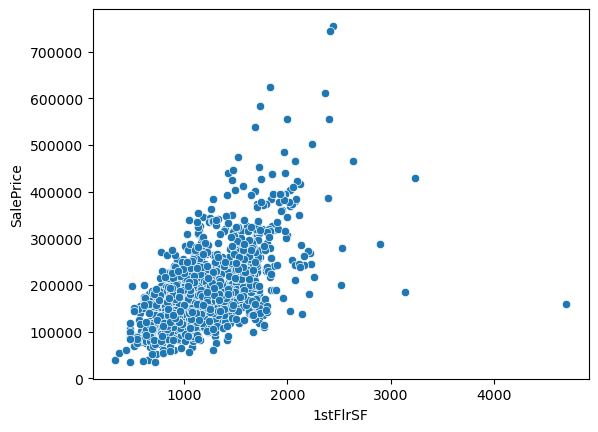

In [202]:
sns.scatterplot(x = '1stFlrSF', y = 'SalePrice', data = TrainDF_HousingData)

## 2ndFlrSF Feature

In [203]:
TrainDF_HousingData['2ndFlrSF'].min()

0

In [204]:
TrainDF_HousingData['2ndFlrSF'].max()

2065

In [205]:
sum(TrainDF_HousingData['2ndFlrSF'].isnull())

0

<Axes: xlabel='2ndFlrSF', ylabel='SalePrice'>

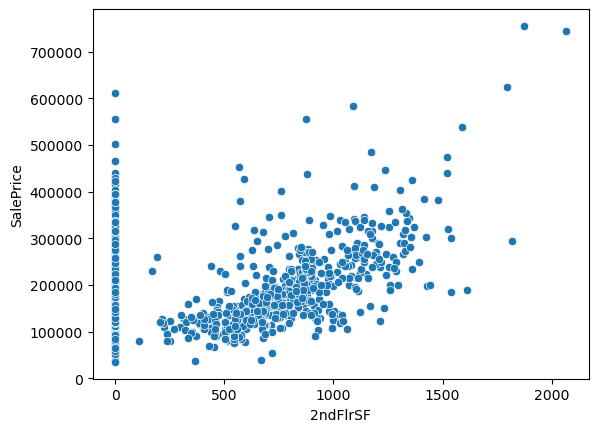

In [206]:
sns.scatterplot(x = '2ndFlrSF', y = 'SalePrice', data = TrainDF_HousingData)

## LowQualFinSF Feature

<Axes: xlabel='LowQualFinSF', ylabel='SalePrice'>

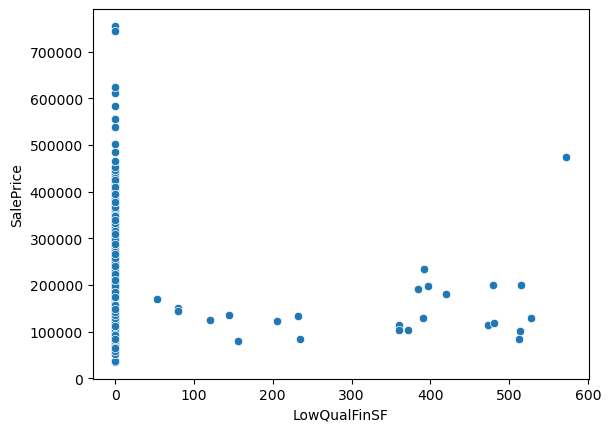

In [208]:
sns.scatterplot(x = 'LowQualFinSF', y = 'SalePrice', data = TrainDF_HousingData)

In [216]:
TrainDF_HousingData.query('LowQualFinSF > 500 and SalePrice > 400000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000


## GrLivArea Feature

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

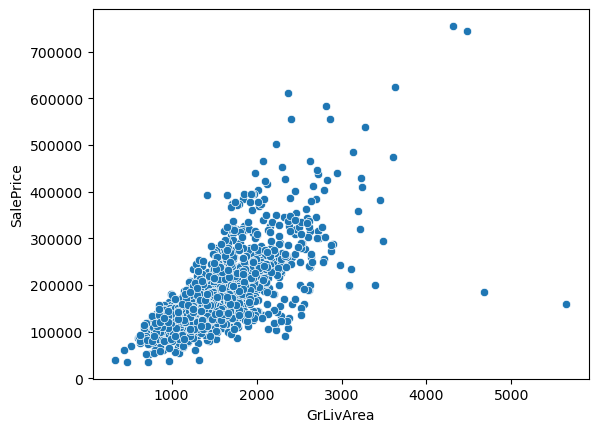

In [217]:
sns.scatterplot(x = 'GrLivArea', y = 'SalePrice', data = TrainDF_HousingData)

In [218]:
TrainDF_HousingData.query('GrLivArea > 4000 and SalePrice < 300000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


## FullBath Feature

<Axes: xlabel='FullBath', ylabel='SalePrice'>

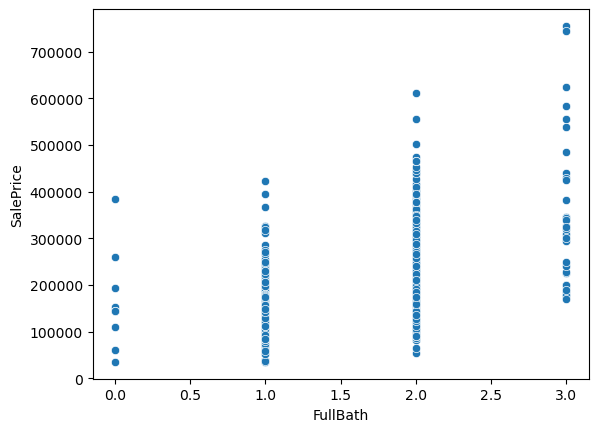

In [219]:
sns.scatterplot(x = 'FullBath', y = 'SalePrice', data = TrainDF_HousingData)

## HalfBath Feature

<Axes: xlabel='HalfBath', ylabel='SalePrice'>

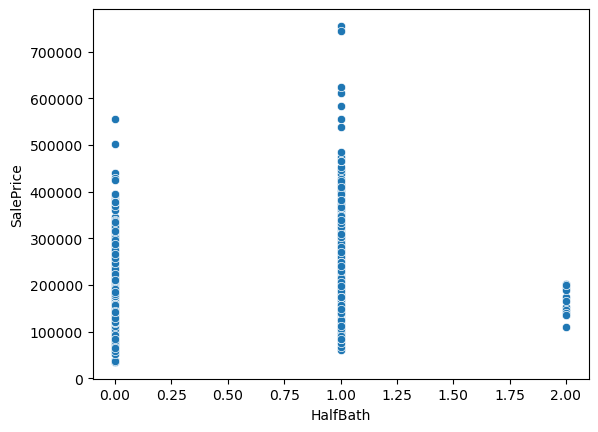

In [246]:
sns.scatterplot(x = 'HalfBath', y = 'SalePrice', data = TrainDF_HousingData)

## BedroomAbvGr Feature

<Axes: xlabel='BedroomAbvGr', ylabel='SalePrice'>

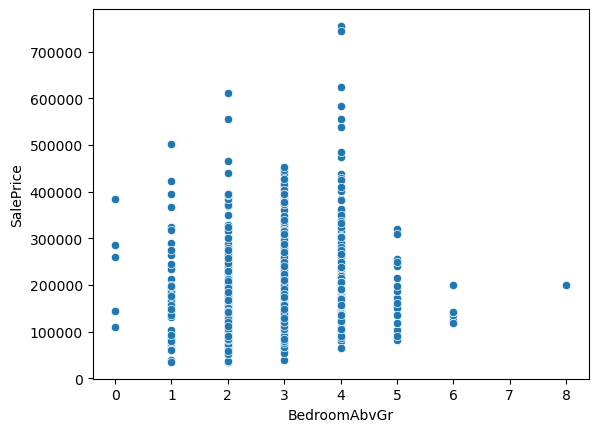

In [247]:
sns.scatterplot(x = 'BedroomAbvGr', y = 'SalePrice', data = TrainDF_HousingData)

In [250]:
np.unique(stats.zscore(TrainDF_HousingData.BedroomAbvGr))

array([-3.51495182, -2.28870817, -1.06246453,  0.16377912,  1.39002276,
        2.61626641,  3.84251005,  6.29499734])

In [252]:
TrainDF_HousingData.query('BedroomAbvGr == 8')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Abnorml,200000


## KitchenAbvGr Featur

<Axes: xlabel='KitchenAbvGr', ylabel='SalePrice'>

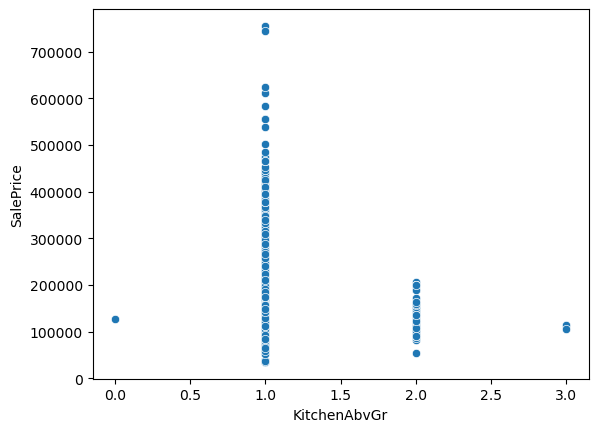

In [255]:
sns.scatterplot(x = 'KitchenAbvGr', y = 'SalePrice', data = TrainDF_HousingData)

In [258]:
TrainDF_HousingData.query('KitchenAbvGr == 0')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
954,955,90,RL,35.0,9400,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2006,WD,AdjLand,127500


In [257]:
TrainDF_HousingData.query('KitchenAbvGr == 3')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
48,49,190,RM,33.0,4456,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,New,Partial,113000
809,810,75,RM,90.0,8100,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,11,2009,WD,Normal,106000


## TotRmsAbvGrd

<Axes: xlabel='TotRmsAbvGrd', ylabel='SalePrice'>

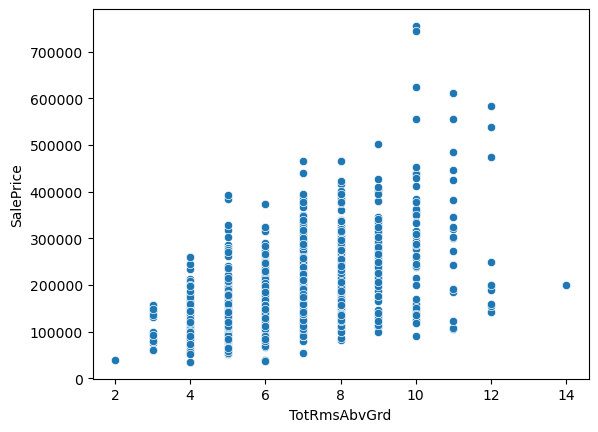

In [259]:
sns.scatterplot(x = 'TotRmsAbvGrd', y = 'SalePrice', data = TrainDF_HousingData)

In [262]:
TrainDF_HousingData.query('TotRmsAbvGrd == 14')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Abnorml,200000


## Fireplaces

<Axes: xlabel='Fireplaces', ylabel='SalePrice'>

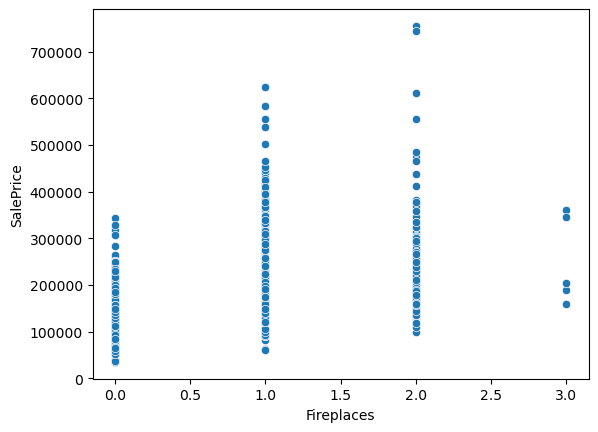

In [273]:
sns.scatterplot(x = 'Fireplaces', y = 'SalePrice', data = TrainDF_HousingData)

## WoodDeckSF Feature

<Axes: xlabel='WoodDeckSF', ylabel='SalePrice'>

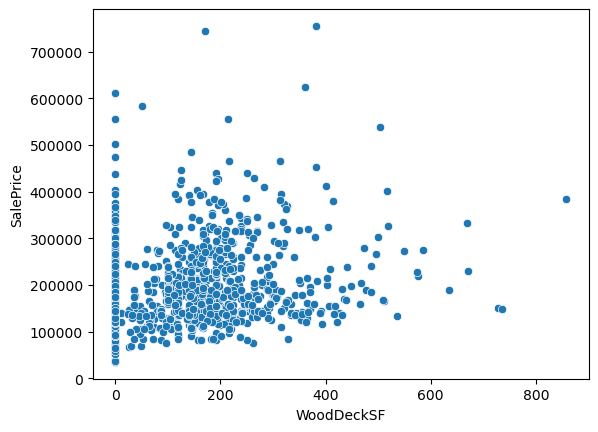

In [272]:
sns.scatterplot(x = 'WoodDeckSF', y = 'SalePrice', data = TrainDF_HousingData)

In [274]:
TrainDF_HousingData.query('WoodDeckSF == 14')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


## OpenPorchSF Feature

<Axes: xlabel='OpenPorchSF', ylabel='SalePrice'>

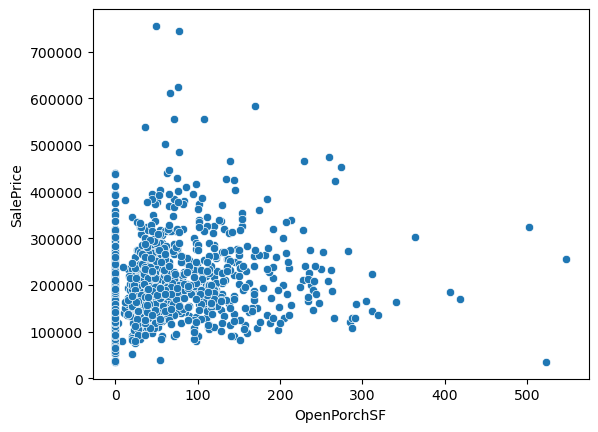

In [275]:
sns.scatterplot(x = 'OpenPorchSF', y = 'SalePrice', data = TrainDF_HousingData)

In [277]:
TrainDF_HousingData.query('OpenPorchSF > 500 and SalePrice < 100000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
495,496,30,C (all),60.0,7879,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdWo,NaN,0,11,2009,WD,Abnorml,34900


## EnclosedPorch Feature

<Axes: xlabel='EnclosedPorch', ylabel='SalePrice'>

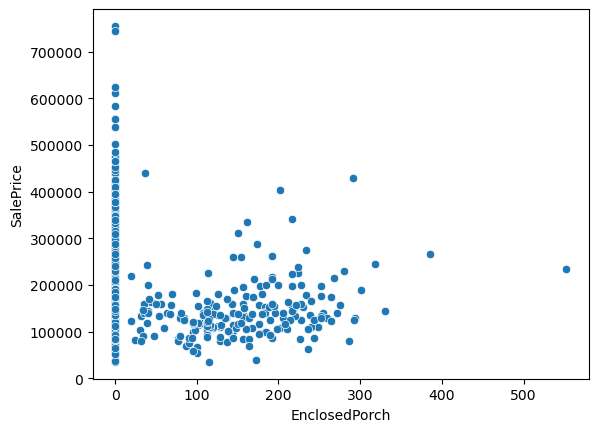

In [278]:
sns.scatterplot(x = 'EnclosedPorch', y = 'SalePrice', data = TrainDF_HousingData)

In [279]:
TrainDF_HousingData.query('EnclosedPorch > 500')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
197,198,75,RL,174.0,25419,Pave,NaN,Reg,Lvl,AllPub,...,512,Ex,GdPrv,NaN,0,3,2006,WD,Abnorml,235000


## 3SsnPorch Feature

<Axes: xlabel='3SsnPorch', ylabel='SalePrice'>

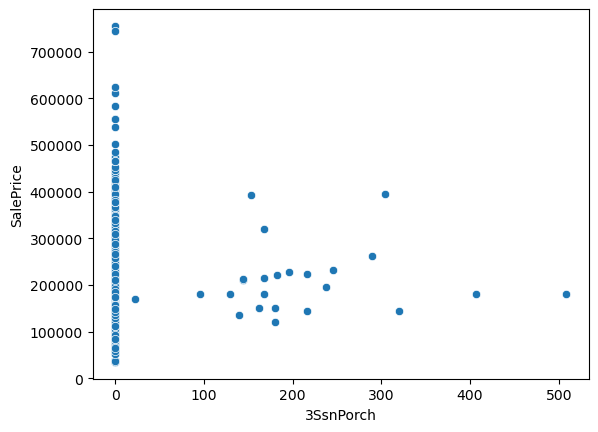

In [281]:
sns.scatterplot(x = '3SsnPorch', y = 'SalePrice', data = TrainDF_HousingData)

## ScreenPorch Feature

<Axes: xlabel='ScreenPorch', ylabel='SalePrice'>

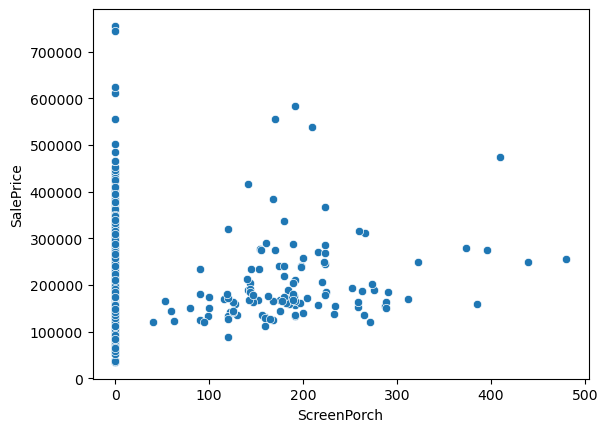

In [282]:
sns.scatterplot(x = 'ScreenPorch', y = 'SalePrice', data = TrainDF_HousingData)

## PoolArea Feature

<Axes: xlabel='PoolArea', ylabel='SalePrice'>

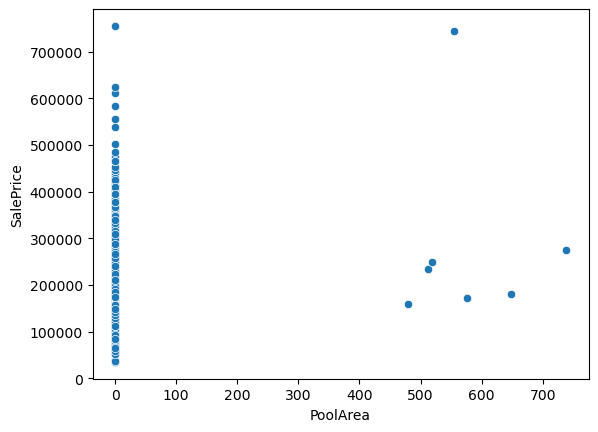

In [284]:
sns.scatterplot(x = 'PoolArea', y = 'SalePrice', data = TrainDF_HousingData)

## MiscVal Feature

<Axes: xlabel='MiscVal', ylabel='SalePrice'>

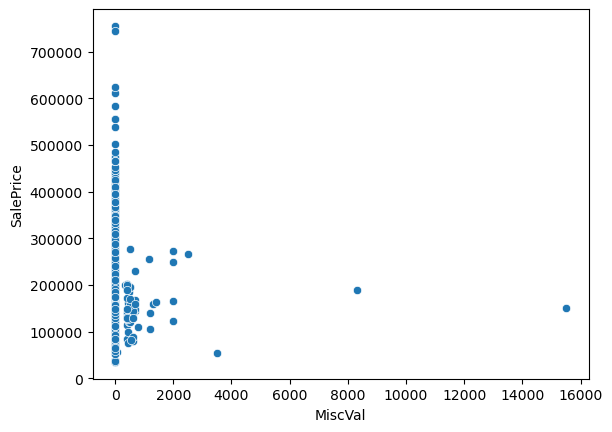

In [285]:
sns.scatterplot(x = 'MiscVal', y = 'SalePrice', data = TrainDF_HousingData)

In [286]:
TrainDF_HousingData.query('MiscVal >8000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
346,347,20,RL,NaN,12772,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,15500,4,2007,WD,Normal,151500
1230,1231,90,RL,NaN,18890,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,8300,8,2007,WD,Normal,190000


## MoSold Feature

<Axes: xlabel='MoSold', ylabel='SalePrice'>

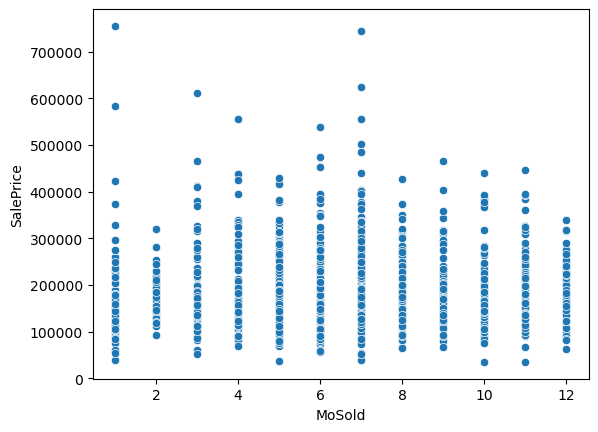

In [287]:
sns.scatterplot(x = 'MoSold', y = 'SalePrice', data = TrainDF_HousingData)

## YrSold Feature

<Axes: xlabel='YrSold', ylabel='SalePrice'>

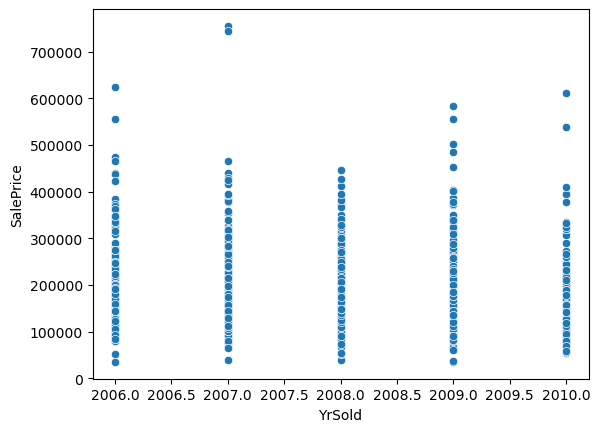

In [288]:
sns.scatterplot(x = 'YrSold', y = 'SalePrice', data = TrainDF_HousingData)